# K testr

In [1]:
# libraries
import os
import glob
import numpy as np
from datetime import datetime, timedelta
import math as m

from netCDF4 import Dataset

from snobedo.input import HrrrParameter, SmrfTopo
from snobedo.shortwave import TopoShade
from snobedo.input import SmrfTopo

import matplotlib.pyplot as plt

from topocalc.horizon import horizon
from topocalc.shade import shade

# cusotm functions
import topo_split as tsw


# paths
UVU_OLSON_HOME = '/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/'
HRRR_DATA = UVU_OLSON_HOME + 'HRRR_2022/'
ERW_TOPO_FILE = UVU_OLSON_HOME + 'isnobal-data/ERW_topo.nc'

# Set the PROJ_LIB environment variable
os.environ['PROJ_LIB'] = '/uufs/chpc.utah.edu/common/home/skiles-group1/jmeyer/conda/envs/smeshr/share/proj' 

# STATIC VARIABLES
dem, sky_view_factor, topo_shade = tsw.static_topo_vars(ERW_TOPO_FILE)

In [2]:
h_test = HrrrParameter(ERW_TOPO_FILE, HRRR_DATA + 'hrrr.20220301/hrrr.t00z.wrfsfcf06.grib2', 'cubic')
h_test.timestep_for_band(10)


datetime.datetime(2022, 3, 1, 6, 0, tzinfo=datetime.timezone.utc)

In [7]:
dem, sky_view_factor, topo_shade = tsw.static_topo_vars(ERW_TOPO_FILE)


hrrr_dir = HRRR_DATA + 'hrrr.20220615'
hrrr_files = sorted(
        glob.glob(
            os.path.join(hrrr_dir, 'hrrr.t*z.wrfsfcf06.grib2')
        )
    )
print(hrrr_files[0])
sample_dswrf = HrrrParameter(ERW_TOPO_FILE, hrrr_files[0]) # make sure is mid-day

_azimuth, zenith, incidence_angles, illumination, cosZ = tsw.hrrr_solar_geom(
    sample_dswrf, topo_shade
)

zenith

/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/HRRR_2022/hrrr.20220615/hrrr.t00z.wrfsfcf06.grib2


{'2022-06-15 06:00': 0,
 '2022-06-15 07:00': 0,
 '2022-06-15 08:00': 0,
 '2022-06-15 09:00': 0,
 '2022-06-15 10:00': 0,
 '2022-06-15 11:00': 89.30898801420602,
 '2022-06-15 12:00': 82.54593484463685,
 '2022-06-15 13:00': 71.56487596369305,
 '2022-06-15 14:00': 60.12500701613034,
 '2022-06-15 15:00': 48.472671348435455,
 '2022-06-15 16:00': 36.90779536770207,
 '2022-06-15 17:00': 26.014982812801627,
 '2022-06-15 18:00': 17.549331741410683,
 '2022-06-15 19:00': 16.21768588149513,
 '2022-06-15 20:00': 23.296408263552507,
 '2022-06-15 21:00': 33.78864130096422,
 '2022-06-15 22:00': 45.248445764667686,
 '2022-06-15 23:00': 56.91050575256961,
 '2022-06-16 00:00': 68.43167033792317,
 '2022-06-16 01:00': 79.56193949016331,
 '2022-06-16 02:00': 87.83903973932252,
 '2022-06-16 03:00': 0,
 '2022-06-16 04:00': 0,
 '2022-06-16 05:00': 0}

  K: 0.0
  K: 0.19
  K: 0.14
  K: 0.11
  K: 0.1
  K: 0.1
  K: 0.1
  K: 0.1
  K: 0.11
  K: 0.13
  K: 0.18
  K: 0.34
  K: 0.82
 
Elevation Ranges (m):
E1 (Low): 2440.31 – 3069.41 m
E2 (Mid): 3069.41 – 3698.51 m
E3 (High): 3698.51 – 4327.61 m


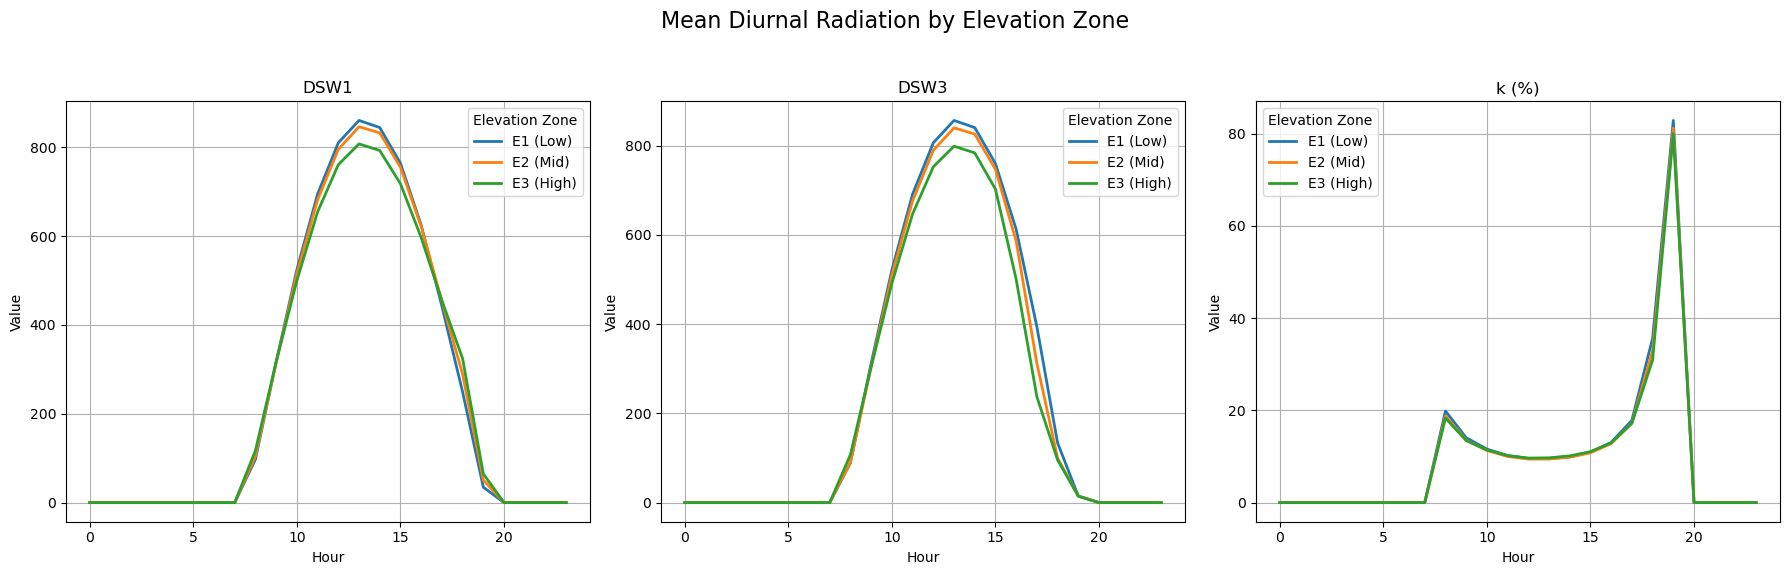

In [8]:
# RUN FOR SINGLE DAY
dem, sky_view_factor, topo_shade = tsw.static_topo_vars(ERW_TOPO_FILE)

hrrr_dir = HRRR_DATA + 'hrrr.20220315'
ghi_stack, dsw1_stack, dsw2_stack, dsw3_stack, dsw3h_stack, k_stack, time_list = tsw.toposplit_for_day(ERW_TOPO_FILE, hrrr_dir, resample_method='cubic')


# PLOT
import numpy as np
import matplotlib.pyplot as plt

# Select variables to plot
arrays = {
    'DSW1': dsw1_stack,
    'DSW3': dsw3_stack,
    'k (%)': k_stack * 100  # Convert k to percent
}

# Time axis (0 to 23 hours)
hours = np.arange(24)

# Define 3 elevation bins using dem
n_bins = 3
bin_labels = ['E1 (Low)', 'E2 (Mid)', 'E3 (High)']
elev_edges = np.linspace(dem.min(), dem.max(), n_bins + 1)

# Create elevation masks
elevation_masks = [
    (dem >= elev_edges[i]) & (dem < elev_edges[i + 1])
    for i in range(n_bins)
]
# Ensure max is included in last bin
elevation_masks[-1] = (dem >= elev_edges[-2]) & (dem <= elev_edges[-1])

# Print bin info
print(" ")
print("Elevation Ranges (m):")
for i, label in enumerate(bin_labels):
    print(f"{label}: {elev_edges[i]:.2f} – {elev_edges[i+1]:.2f} m")

# Plot
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=False)

colors = ['tab:blue', 'tab:orange', 'tab:green']

for ax, (label, arr) in zip(axes, arrays.items()):
    for i, mask in enumerate(elevation_masks):
        # Broadcast mask and extract time series
        masked = np.where(mask, arr, np.nan)
        mean_vals = np.nanmean(masked, axis=(1, 2))  # Mean over spatial dims
        ax.plot(hours, mean_vals, label=bin_labels[i], color=colors[i], linewidth=2)

    ax.set_title(label)
    ax.set_xlabel('Hour')
    ax.set_ylabel('Value')
    ax.grid(True)
    ax.legend(title='Elevation Zone')

plt.suptitle("Mean Diurnal Radiation by Elevation Zone", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

numpy.ndarray

In [15]:
# TEST topocalc function
#
hrrr_dswrf = HrrrParameter(topo_file, hrrr_files[0])
from snobedo.shortwave import TopoShade
topo_file = ERW_TOPO_FILE
topo_shade = TopoShade(
        topo_file, TopoShade.SolarMethods.SKYFIELD
    )
topo_shade2 = TopoShade(
        topo_file, TopoShade.SolarMethods.SKYFIELD
    )
# JOES
time_range = [
        hrrr_dswrf.timestep_for_band(10) + timedelta(hours=hour)
        for hour in range(0, 24)
    ]
# OTHER
hour = hrrr_dswrf.timestep_for_band(10)
start_day = hour.strftime('%Y-%m-%d') 
end_day = (hour + timedelta(days=1)).strftime('%Y-%m-%d')
time_range2 = np.arange(str(start_day), str(end_day), np.timedelta64(1, 'h'), dtype='datetime64[s]')
time_range2 = [datetime.fromisoformat(str(r)) for r in time_range2]
print("Time Range: ")
print(time_range)
print("")
print("Time Range 2: ")
print(time_range2)
print("")
# 
# # # #
# calculate
topo_shade.calculate(time_range)
topo_shade2.calculate(time_range2)

print("")
print("Zenith 1: ")
print(topo_shade.zenith)
print("")
print("Zenith 2: ")
print(topo_shade2.zenith)

Time Range: 
[datetime.datetime(2022, 3, 15, 6, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2022, 3, 15, 7, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2022, 3, 15, 8, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2022, 3, 15, 9, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2022, 3, 15, 10, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2022, 3, 15, 11, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2022, 3, 15, 12, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2022, 3, 15, 13, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2022, 3, 15, 14, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2022, 3, 15, 15, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2022, 3, 15, 16, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2022, 3, 15, 17, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2022, 3, 15, 18, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2022, 3, 15, 19, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2022, 

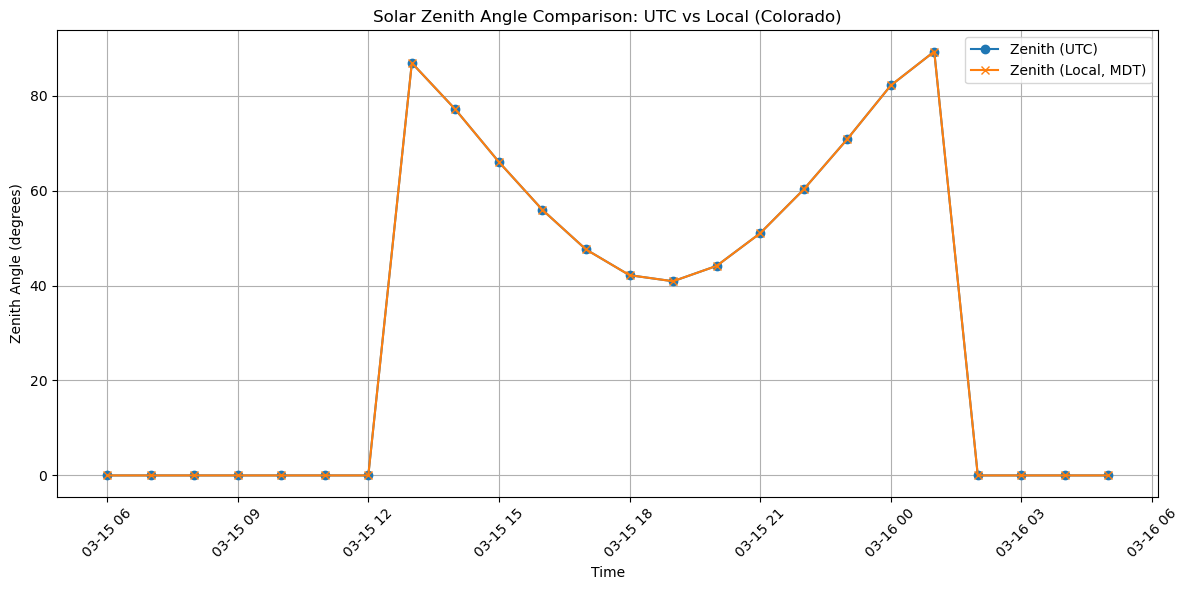

In [20]:
import matplotlib.pyplot as plt
from zoneinfo import ZoneInfo

# Generate local time range (Colorado) correctly
time_range2 = np.arange(np.datetime64(start_day), np.datetime64(end_day), np.timedelta64(1, 'h'))
time_range2 = [datetime.fromisoformat(str(r)).replace(tzinfo=ZoneInfo("America/Denver")) for r in time_range2]

# Recalculate with corrected local times
topo_shade2.calculate(time_range2)

# Extract zenith data
zenith_utc = topo_shade.zenith  # keys are UTC datetime
zenith_local = topo_shade2.zenith  # keys are local datetime

# Sort and extract for plotting
times_utc = sorted(zenith_utc.keys())
values_utc = [zenith_utc[t] for t in times_utc]

times_local = sorted(zenith_local.keys())
values_local = [zenith_local[t] for t in times_local]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(times_utc, values_utc, label='Zenith (UTC)', marker='o')
plt.plot(times_local, values_local, label='Zenith (Local, MDT)', marker='x')

plt.xlabel("Time")
plt.ylabel("Zenith Angle (degrees)")
plt.title("Solar Zenith Angle Comparison: UTC vs Local (Colorado)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
